# World Cup 2026: Verified Real-Data Models

This notebook reports the promoted probabilistic W/D/L model trained from:

- 32,252 completed international matches through **June 10, 2026**
- 346 official FIFA/Coca-Cola Men's World Ranking snapshots
- strict prior-only Elo, rolling form, rest, context, and FIFA as-of features

No random split is used. The primary metric is Log Loss; Brier Score and RPS are
mandatory guardrails. The production artifact contains no mandatory LightGBM or
CatBoost dependency.

In [1]:
from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from football_forecast.evaluation.calibration import multiclass_reliability_tables
from football_forecast.evaluation.metrics import log_loss_multiclass
from football_forecast.features.asof_join import assert_prior_only_timestamps
from football_forecast.features.advanced import tournament_category

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")

## 1. Pinned data and model provenance

In [2]:
RESULTS_MANIFEST = PROJECT_ROOT / "data/raw/martj42_international_results/source_manifest.json"
FIFA_MANIFEST = PROJECT_ROOT / "data/raw/fifa_rankings/source_manifest.json"
FEATURES_PATH = PROJECT_ROOT / "data/processed/features_fifa_1990_2026-06-10.parquet"
MODEL_PATH = PROJECT_ROOT / "models/world_cup_2026_champion.joblib"
MODEL_METADATA_PATH = PROJECT_ROOT / "models/world_cup_2026_champion.metadata.json"

results_manifest = json.loads(RESULTS_MANIFEST.read_text(encoding="utf-8"))
fifa_manifest = json.loads(FIFA_MANIFEST.read_text(encoding="utf-8"))
metadata = json.loads(MODEL_METADATA_PATH.read_text(encoding="utf-8"))
features = pd.read_parquet(FEATURES_PATH)
model = joblib.load(MODEL_PATH)

provenance = pd.Series({
    "match_source_commit": results_manifest["commit"],
    "match_source_sha256": results_manifest["sha256"],
    "fifa_page_build_id": fifa_manifest["page_build_id"],
    "fifa_page_sha256": fifa_manifest["page_sha256"],
    "fifa_snapshots": fifa_manifest["snapshot_count"],
    "fifa_rows": fifa_manifest["row_count"],
    "fifa_unmatched_names": len(fifa_manifest["unmatched_to_results"]),
    "completed_matches": len(features),
    "feature_count": metadata["feature_count"],
    "training_cutoff_exclusive": metadata["production_training_cutoff_exclusive"],
    "model_sha256": metadata["model_sha256"],
}, name="value").to_frame()
provenance

,value
match_source_commit,c636851f6e388d7aabd1feabbd4dad94e7e6e266
match_source_sha256,50f17eb331a3d8367184f3314cf41616782f842ebb39e4...
fifa_page_build_id,0-ZXhkYnWdNxG_JfZhYJx
fifa_page_sha256,469a686a4bd93648bf6312251faea1f63870f8899a4f74...
fifa_snapshots,346
fifa_rows,70215
fifa_unmatched_names,0
completed_matches,32252
feature_count,114
training_cutoff_exclusive,2026-06-11T00:00:00Z


## 2. Leakage and probability contracts

In [3]:
assert features["match_id"].is_unique
assert features["kickoff_utc"].max() < pd.Timestamp("2026-06-11T00:00:00Z")
assert fifa_manifest["unmatched_to_results"] == []
assert_prior_only_timestamps(
    features,
    [
        "elo_team1_available_at",
        "elo_team2_available_at",
        "team1_history_available_at",
        "team2_history_available_at",
        "team1_fifa_available_at",
        "team2_fifa_available_at",
    ],
)

fifa_coverage = pd.Series({
    "team1": features["team1_fifa_points"].notna().mean(),
    "team2": features["team2_fifa_points"].notna().mean(),
}, name="coverage").to_frame()
fifa_coverage.style.format("{:.2%}")

,coverage
team1,90.49%
team2,90.12%


In [4]:
sanity_probabilities = model.predict_proba(
    features[metadata["feature_columns"]].tail(100)
)
assert sanity_probabilities.shape == (100, 3)
assert np.isfinite(sanity_probabilities).all()
assert ((sanity_probabilities >= 0) & (sanity_probabilities <= 1)).all()
assert np.allclose(sanity_probabilities.sum(axis=1), 1.0)
pd.DataFrame(
    sanity_probabilities[:5],
    columns=["p_team2_win", "p_draw", "p_team1_win"],
)

C:\Users\User\anaconda3\envs\trade310\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\User\anaconda3\envs\trade310\lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,p_team2_win,p_draw,p_team1_win
0,0.043972,0.158916,0.797112
1,0.304343,0.331774,0.363882
2,0.055763,0.150970,0.793267
3,0.239020,0.330435,0.430545
4,0.303612,0.298872,0.397517


## 3. Model and chronological selection

In [5]:
model_design = pd.Series({
    "component_1": "Multinomial logistic regression, C=3.0, 20-year recency half-life",
    "component_2": "HistGradientBoosting, 7 leaves, 350 iterations",
    "logistic_weight": metadata["weights"]["logistic_fifa"],
    "hist_gbm_weight": metadata["weights"]["hist_gbm_fifa"],
    "features": metadata["feature_count"],
    "validation_years": "2018, 2021, 2022, 2023, 2024",
    "holdout": "2025-01-01 through 2026-06-10",
    "promoted": metadata["promoted"],
}, name="value").to_frame()
model_design

,value
component_1,"Multinomial logistic regression, C=3.0, 20-yea..."
component_2,"HistGradientBoosting, 7 leaves, 350 iterations"
logistic_weight,0.678511
hist_gbm_weight,0.321489
features,114
validation_years,"2018, 2021, 2022, 2023, 2024"
holdout,2025-01-01 through 2026-06-10
promoted,True


In [6]:
validation = pd.read_csv(
    PROJECT_ROOT / "reports/champion_model/validation_results.csv"
).sort_values("log_loss")
validation

,model,split,log_loss,brier,rps,accuracy,calibration_error,sharpness,n_matches
0,logistic_fifa_hist_gbm_blend,pooled_rolling_origin,0.867119,0.509433,0.168529,0.606759,0.008977,0.607717,5297
1,compact_no_fifa_baseline,pooled_rolling_origin,0.876381,0.515282,0.171265,0.601850,0.016308,0.607459,5297


In [7]:
validation_baseline = validation.loc[
    validation["model"] == "compact_no_fifa_baseline", "log_loss"
].iloc[0]
validation_champion = validation.loc[
    validation["model"] == "logistic_fifa_hist_gbm_blend", "log_loss"
].iloc[0]
validation_gain = (validation_baseline - validation_champion) / validation_baseline
print(f"Rolling-origin Log Loss improvement: {validation_gain:.2%}")
print(metadata["validation_decision"])

Rolling-origin Log Loss improvement: 1.06%
Log Loss improved by 1.06% without material Brier/RPS degradation


## 4. Holdout results and mandatory baselines

In [8]:
legacy = pd.read_csv(PROJECT_ROOT / "reports/real_model_search/test_results.csv")
champion_holdout = pd.read_csv(
    PROJECT_ROOT / "reports/champion_model/holdout_results.csv"
)
comparison = pd.concat([
    legacy.loc[legacy["model"].isin([
        "class_prior",
        "elo_logistic",
        "poisson_a0.03_hl8.0",
        "logistic_c1.0_hl8.0__raw",
    ])],
    champion_holdout,
], ignore_index=True).sort_values("log_loss")
comparison[[
    "model", "log_loss", "brier", "rps", "accuracy",
    "calibration_error", "sharpness", "n_matches"
]]

,model,log_loss,brier,rps,accuracy,calibration_error,sharpness,n_matches
4,logistic_fifa_hist_gbm_blend,0.815270,0.478736,0.156308,0.619266,0.025374,0.609245,1308
5,compact_no_fifa_baseline,0.832533,0.488663,0.160892,0.613150,0.027864,0.607705,1308
0,logistic_c1.0_hl8.0__raw,0.837341,0.491362,0.162010,0.610092,0.030078,0.610265,1308
1,poisson_a0.03_hl8.0,0.841130,0.493088,0.162915,0.607798,0.040804,0.610544,1308
2,elo_logistic,0.855043,0.503057,0.166858,0.600917,0.025664,0.607674,1308
3,class_prior,1.044538,0.629172,0.227205,0.487768,0.002372,0.485396,1308


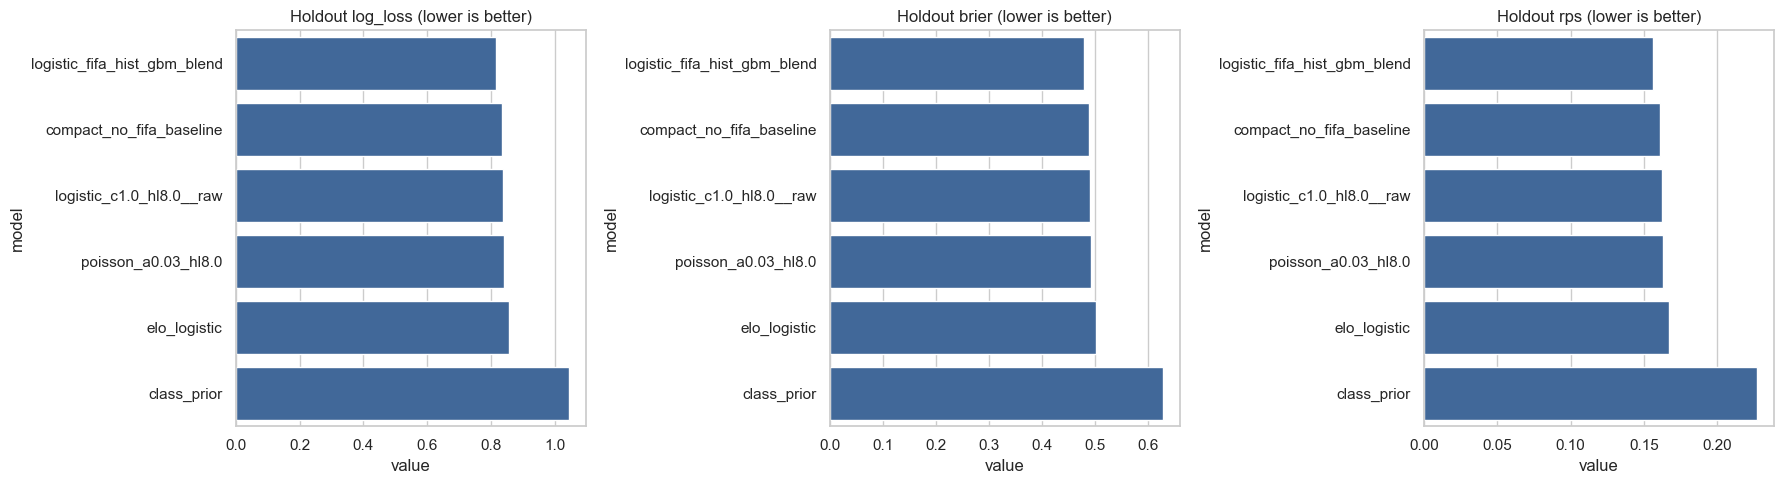

In [9]:
metrics_long = comparison.melt(
    id_vars="model",
    value_vars=["log_loss", "brier", "rps"],
    var_name="metric",
    value_name="value",
)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis, metric in zip(axes, ["log_loss", "brier", "rps"]):
    subset = metrics_long[metrics_long["metric"] == metric].sort_values("value")
    sns.barplot(data=subset, x="value", y="model", ax=axis, color="#3267a8")
    axis.set_title(f"Holdout {metric} (lower is better)")
plt.tight_layout()
plt.show()

In [10]:
baseline = champion_holdout.loc[
    champion_holdout["model"] == "compact_no_fifa_baseline"
].iloc[0]
champion = champion_holdout.loc[
    champion_holdout["model"] == "logistic_fifa_hist_gbm_blend"
].iloc[0]
gains = pd.Series({
    "Log Loss": (baseline["log_loss"] - champion["log_loss"]) / baseline["log_loss"],
    "Brier": (baseline["brier"] - champion["brier"]) / baseline["brier"],
    "RPS": (baseline["rps"] - champion["rps"]) / baseline["rps"],
    "Accuracy": champion["accuracy"] - baseline["accuracy"],
}, name="improvement")
gains.to_frame().style.format("{:.2%}")

,improvement
Log Loss,2.07%
Brier,2.03%
RPS,2.85%
Accuracy,0.61%


## 5. Reliability and holdout slices

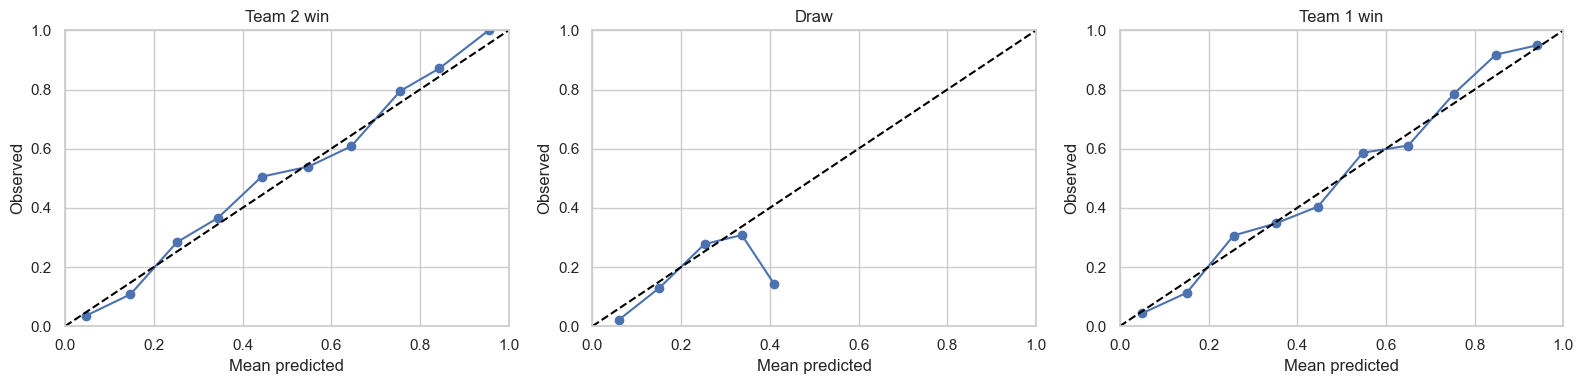

In [11]:
predictions = pd.read_csv(
    PROJECT_ROOT / "reports/champion_model/holdout_predictions.csv"
)
probability_columns = ["p_team2_win", "p_draw", "p_team1_win"]
tables = multiclass_reliability_tables(
    predictions["outcome"].to_numpy(),
    predictions[probability_columns].to_numpy(),
    n_bins=10,
)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for klass, (axis, title) in enumerate(zip(
    axes, ["Team 2 win", "Draw", "Team 1 win"]
)):
    table = tables[klass]
    axis.plot(table["mean_predicted"], table["empirical_rate"], marker="o")
    axis.plot([0, 1], [0, 1], linestyle="--", color="black")
    axis.set(title=title, xlabel="Mean predicted", ylabel="Observed")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [12]:
holdout_context = features.loc[
    features["match_id"].isin(predictions["match_id"]),
    ["match_id", "neutral", "tournament", "elo_diff_pre"],
].copy()
diagnostics = predictions.merge(holdout_context, on="match_id", how="left")
diagnostics["tournament_category"] = diagnostics["tournament"].map(tournament_category)
diagnostics["elo_gap"] = pd.cut(
    diagnostics["elo_diff_pre"].abs(),
    bins=[-np.inf, 50, 150, 300, np.inf],
    labels=["0-50", "50-150", "150-300", "300+"],
)

slice_rows = []
for dimension in ["neutral", "tournament_category", "elo_gap"]:
    for value, group in diagnostics.groupby(dimension, observed=True):
        slice_rows.append({
            "dimension": dimension,
            "value": str(value),
            "matches": len(group),
            "log_loss": log_loss_multiclass(
                group["outcome"].to_numpy(),
                group[probability_columns].to_numpy(),
            ),
        })
pd.DataFrame(slice_rows).sort_values(["dimension", "log_loss"])

,dimension,value,matches,log_loss
11,elo_gap,300+,195,0.323783
10,elo_gap,150-300,386,0.728367
9,elo_gap,50-150,442,0.950364
8,elo_gap,0-50,285,1.059737
0,neutral,False,878,0.797207
1,neutral,True,430,0.852153
3,tournament_category,continental_qualifier,80,0.693808
7,tournament_category,world_cup_qualifier,508,0.752481
2,tournament_category,continental_final,83,0.766942
4,tournament_category,friendly,426,0.860912


## 6. Interpretable logistic feature strength

In [13]:
logistic_pipeline = model.models[0].model
coefficients = logistic_pipeline.named_steps["model"].coef_
importance = pd.DataFrame({
    "feature": metadata["feature_columns"],
    "coefficient_l2": np.sqrt((coefficients ** 2).sum(axis=0)),
}).sort_values("coefficient_l2", ascending=False)
importance.head(25)

,feature,coefficient_l2
17,opponent_adjusted_goal_diff_ewm_diff,3.743908
14,goal_diff_ewm_diff,0.996135
65,matchup_goals_ewm_diff,0.996135
16,goals_against_ewm_diff,0.868673
15,goals_for_ewm_diff,0.795838
1,elo_exp_team1,0.763575
99,fifa_rank_percentile_diff,0.757386
9,opponent_adjusted_goal_diff_roll10_diff,0.511467
96,fifa_rank_diff,0.505149
94,team2_fifa_rank_percentile,0.465874


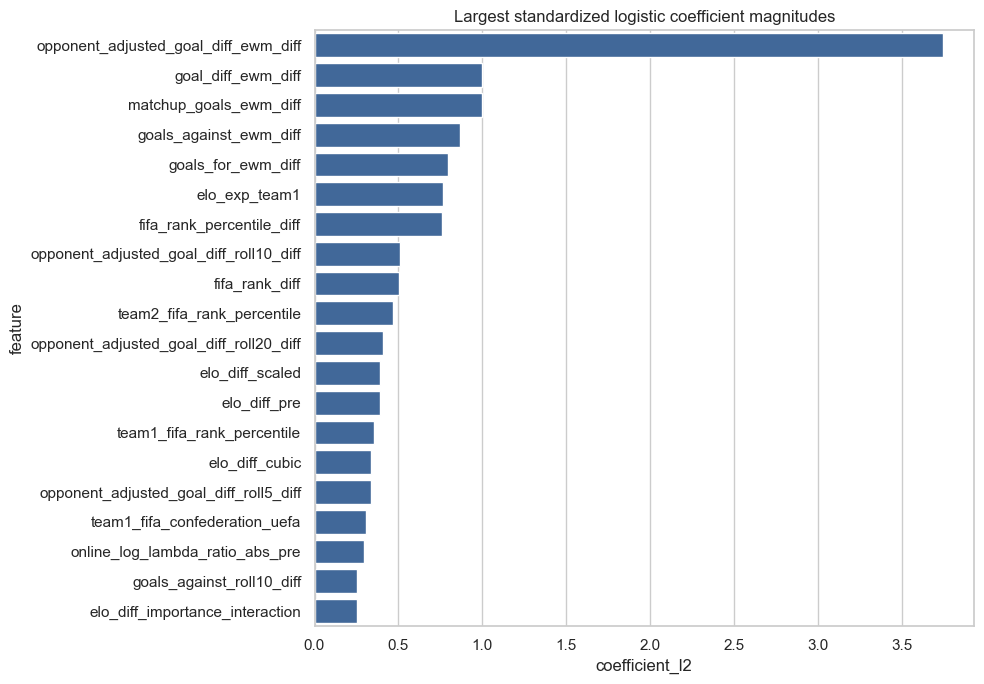

In [14]:
plt.figure(figsize=(10, 7))
sns.barplot(
    data=importance.head(20),
    x="coefficient_l2",
    y="feature",
    color="#3267a8",
)
plt.title("Largest standardized logistic coefficient magnitudes")
plt.tight_layout()
plt.show()

## Conclusion

The champion passed both repository promotion gates:

- **Rolling-origin validation:** 1.06% lower Log Loss than the strongest
  no-FIFA model, with better Brier and RPS.
- **2025-2026 holdout:** 2.07% lower Log Loss, 2.03% lower Brier, and 2.85%
  lower RPS.

The production model was refit on all 32,252 matches through June 10, 2026 and
saved as `models/world_cup_2026_champion.joblib`.

The holdout had been observed during earlier repository iterations; this is
recorded in the metadata. Model selection in this run used pooled historical
rolling-origin predictions, and the fixed holdout was opened only after the
candidate was selected.